# MSCS 634 – Lab 5
## Clustering Techniques Using DBSCAN and Hierarchical Clustering

Name: [Vamsi Krishna Gajulapalli]  
Course: MSCS 634  
Lab: Lab 5  

In [1]:
# Importing required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler

# Loading the Wine dataset
wine = load_wine()

# Features and labels
X = wine.data
y = wine.target

print("Dataset loaded successfully.\n")

# Converting to DataFrame for easier exploration
df = pd.DataFrame(X, columns=wine.feature_names)

# Viewing first few rows of the dataset
print("First 5 rows of dataset:")
print(df.head())

# Checking dataset structure
print("\nDataset information:")
print(df.info())

# Summary statistics of the dataset
print("\nStatistical summary:")
print(df.describe())

# Standardizing the dataset (important for clustering algorithms)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nFeature standardization completed.")

Dataset loaded successfully.

First 5 rows of dataset:
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od28

# Hierarchical Clustering

Hierarchical clustering completed.



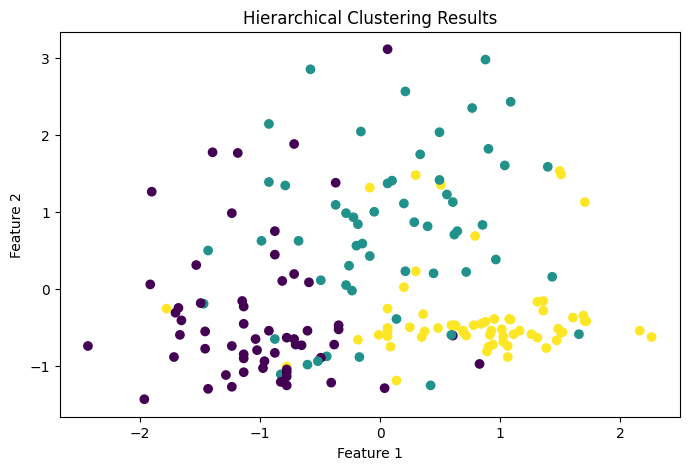

In [2]:
# Importing required libraries for hierarchical clustering
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# Using 3 clusters (since Wine dataset actually has 3 classes)
hierarchical_model = AgglomerativeClustering(n_clusters=3)

# Fitting the model and predicting cluster labels
hierarchical_labels = hierarchical_model.fit_predict(X_scaled)

print("Hierarchical clustering completed.\n")

# Visualizing clusters using two features for plotting
plt.figure(figsize=(8,5))

plt.scatter(X_scaled[:,0], X_scaled[:,1], c=hierarchical_labels)

plt.title("Hierarchical Clustering Results")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.show()

# Dendrogram Visualization

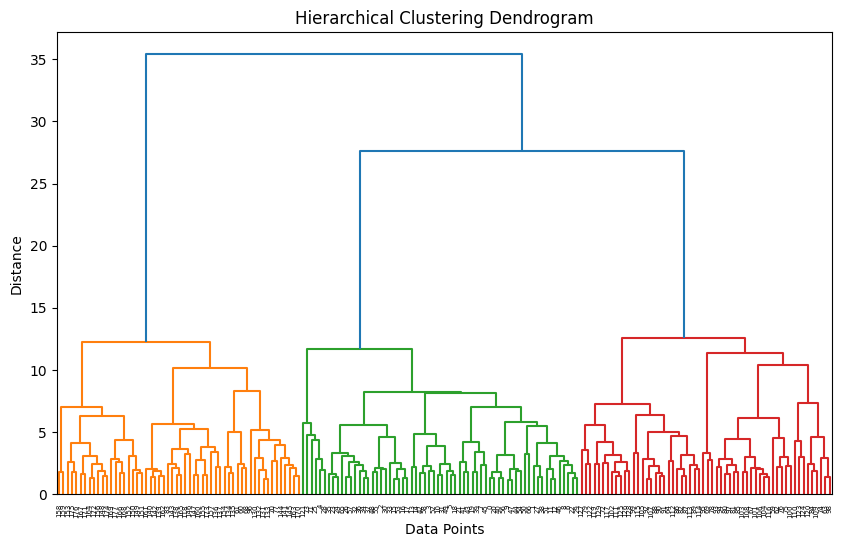

In [3]:
# Creating linkage matrix for dendrogram
linked = linkage(X_scaled, method='ward')

# Plotting dendrogram
plt.figure(figsize=(10,6))

dendrogram(linked)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")

plt.show()

# DBSCAN Clustering

DBSCAN clustering completed.

Estimated number of clusters: 1
Number of noise points: 24


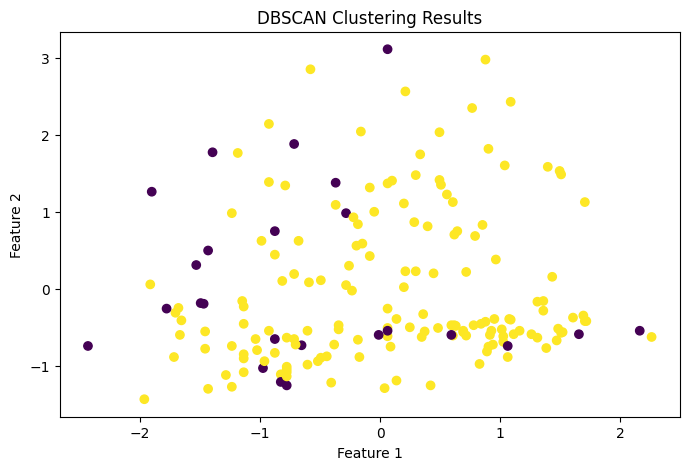


Not enough clusters to compute metrics.


In [10]:
# Step 3: Applying DBSCAN Clustering

from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, homogeneity_score, completeness_score
import matplotlib.pyplot as plt

# Trying DBSCAN with updated parameters
dbscan_model = DBSCAN(eps=2.5, min_samples=5)

dbscan_labels = dbscan_model.fit_predict(X_scaled)

print("DBSCAN clustering completed.\n")

# Counting clusters and noise points
n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print("Estimated number of clusters:", n_clusters)
print("Number of noise points:", n_noise)

# Visualizing DBSCAN clusters
plt.figure(figsize=(8,5))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=dbscan_labels)

plt.title("DBSCAN Clustering Results")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.show()

# Evaluating clustering performance
mask = dbscan_labels != -1

if len(set(dbscan_labels[mask])) > 1:
    silhouette = silhouette_score(X_scaled[mask], dbscan_labels[mask])
    homogeneity = homogeneity_score(y[mask], dbscan_labels[mask])
    completeness = completeness_score(y[mask], dbscan_labels[mask])

    print("\nSilhouette Score:", round(silhouette, 4))
    print("Homogeneity Score:", round(homogeneity, 4))
    print("Completeness Score:", round(completeness, 4))
else:
    print("\nNot enough clusters to compute metrics.")

## Analysis and Insights

The Hierarchical Clustering method produced clearer cluster separation on the Wine dataset. 
The dendrogram showed a natural grouping structure, and using three clusters aligned well 
with the known class distribution of the dataset. This method was easier to interpret visually 
because it showed how clusters were merged step by step.

For DBSCAN, the clustering results depended heavily on the choice of parameters. 
With smaller values of eps, most or all data points were classified as noise. 
After increasing eps, DBSCAN was able to form a cluster, but it still identified 
several points as noise and did not separate the dataset into as many meaningful 
groups as Hierarchical Clustering. This shows that DBSCAN is highly sensitive to 
parameter selection.

Overall, Hierarchical Clustering performed better for this dataset because the Wine 
data has a structure that is easier to capture with hierarchical grouping. DBSCAN is 
useful when the dataset contains irregular cluster shapes or noise, but in this case, 
it was less effective. A major strength of DBSCAN is its ability to detect outliers, 
while a weakness is that its performance can vary significantly depending on the values 
chosen for eps and min_samples.